In [5]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression  # Cambiar LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  # Métricas para regresión

In [6]:
# URL del archivo en el bucket público de AWS
url = "https://hybridge-education-machine-learning-datasets.s3.us-east-1.amazonaws.com/Fraud.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
len(df)

6362620

# ¡¡¡6,362,620 OBSERVACIONES!!!

#La primera vez que corri y prepare los datos para entrenamiento me aparecio error debido a la cantidad de observaciones

In [8]:
# Identificar columnas que probablemente son IDs o no útiles
columnas_a_eliminar = []

# Busca columnas que puedan ser IDs únicos
for col in X.columns:
    if X[col].nunique() == len(X):  # Si todos los valores son únicos
        print(f"⚠️ '{col}' tiene todos valores únicos (probablemente un ID)")
        columnas_a_eliminar.append(col)
    elif X[col].nunique() > 1000 and X[col].dtype == 'object':  # Muchas categorías
        print(f"⚠️ '{col}' tiene {X[col].nunique()} valores únicos")
        columnas_a_eliminar.append(col)

# Eliminar columnas problemáticas
X = X.drop(columns=columnas_a_eliminar)

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Cargar datos
url = "https://hybridge-education-machine-learning-datasets.s3.us-east-1.amazonaws.com/Fraud.csv"
df = pd.read_csv(url)

print(f"Forma original del dataset: {df.shape}")
print(f"\nColumnas originales:\n{list(df.columns)}")

# Separar X e y
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# ============================================
# PASO 1: Eliminar columnas ID
# ============================================
columnas_a_eliminar = []

for col in X.columns:
    n_unique = X[col].nunique()
    porcentaje_unique = (n_unique / len(X)) * 100
    
    # Si más del 95% de los valores son únicos, probablemente es un ID
    if porcentaje_unique > 95:
        print(f"❌ Eliminando '{col}': {n_unique} valores únicos ({porcentaje_unique:.1f}%)")
        columnas_a_eliminar.append(col)

X = X.drop(columns=columnas_a_eliminar)
print(f"\n✅ Forma después de eliminar IDs: {X.shape}")

# ============================================
# PASO 2: Identificar columnas categóricas
# ============================================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("\n" + "="*60)
print("ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("="*60)

for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Valores únicos: {X[col].nunique()}")
    print(f"  Primeros valores: {X[col].unique()[:5]}")

# ============================================
# PASO 3: Separar por cardinalidad
# ============================================
low_card_cols = [col for col in categorical_cols if X[col].nunique() < 10]
high_card_cols = [col for col in categorical_cols if X[col].nunique() >= 10]

print(f"\n📊 Columnas baja cardinalidad (< 10): {low_card_cols}")
print(f"📊 Columnas alta cardinalidad (>= 10): {high_card_cols}")

# ============================================
# PASO 4: Aplicar One-Hot Encoding (baja cardinalidad)
# ============================================
if len(low_card_cols) > 0:
    print(f"\n✅ Aplicando One-Hot Encoding a: {low_card_cols}")
    X = pd.get_dummies(X, columns=low_card_cols, drop_first=True)
    print(f"   Forma después de One-Hot: {X.shape}")

# ============================================
# PASO 5: Aplicar Label Encoding (alta cardinalidad)
# ============================================
# IMPORTANTE: Ahora recalculamos las columnas categóricas restantes
categorical_cols_remaining = X.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols_remaining) > 0:
    print(f"\n✅ Aplicando Label Encoding a: {categorical_cols_remaining}")
    le = LabelEncoder()
    for col in categorical_cols_remaining:
        X[col] = le.fit_transform(X[col].astype(str))
        print(f"   - {col} codificado")

# ============================================
# PASO 6: Verificar y manejar valores nulos
# ============================================
if X.isnull().sum().sum() > 0:
    print(f"\n⚠️ Valores nulos encontrados: {X.isnull().sum().sum()}")
    # Rellenar valores nulos solo en columnas numéricas
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].mean())
    print("✅ Valores nulos rellenados con la media")

# ============================================
# VERIFICACIÓN FINAL
# ============================================
print("\n" + "="*60)
print("DATASET FINAL")
print("="*60)
print(f"Forma final: {X.shape}")
print(f"Tipos de datos:\n{X.dtypes.value_counts()}")
print(f"¿Hay valores nulos?: {X.isnull().sum().sum()}")
print(f"¿Hay columnas no numéricas?: {len(X.select_dtypes(exclude=[np.number]).columns)}")

Forma original del dataset: (6362620, 11)

Columnas originales:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
❌ Eliminando 'nameOrig': 6353307 valores únicos (99.9%)

✅ Forma después de eliminar IDs: (6362620, 9)

ANÁLISIS DE VARIABLES CATEGÓRICAS

type:
  Valores únicos: 5


/tmp/ipykernel_8160/2662014069.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


  Primeros valores: <StringArray>
['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
Length: 5, dtype: str

nameDest:
  Valores únicos: 2722362
  Primeros valores: <StringArray>
['M1979787155', 'M2044282225', 'C553264065', 'C38997010', 'M1230701703']
Length: 5, dtype: str

📊 Columnas baja cardinalidad (< 10): ['type']
📊 Columnas alta cardinalidad (>= 10): ['nameDest']

✅ Aplicando One-Hot Encoding a: ['type']
   Forma después de One-Hot: (6362620, 12)

✅ Aplicando Label Encoding a: ['nameDest']


/tmp/ipykernel_8160/2662014069.py:68: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_remaining = X.select_dtypes(include=['object']).columns.tolist()


   - nameDest codificado

DATASET FINAL
Forma final: (6362620, 12)
Tipos de datos:
float64    5
bool       4
int64      3
Name: count, dtype: int64
¿Hay valores nulos?: 0
¿Hay columnas no numéricas?: 4


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar modelo
modelo = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

modelo.fit(X_train_scaled, y_train)
print("\n✅ ¡Modelo entrenado exitosamente!")

# Evaluar
from sklearn.metrics import classification_report, confusion_matrix

y_pred = modelo.predict(X_test_scaled)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


✅ ¡Modelo entrenado exitosamente!

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1270881
           1       0.03      0.98      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.96      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



In [14]:
# ============================================
# PASO 1: HACER PREDICCIONES
# ============================================
# Predicciones de clase (0 o 1)
y_pred = modelo.predict(X_test_scaled)

# Predicciones de probabilidad (esto es lo que faltaba)
y_pred_proba = modelo.predict_proba(X_test_scaled)[:, 1]

print("✅ Predicciones calculadas correctamente")
print(f"Forma de y_pred: {y_pred.shape}")
print(f"Forma de y_pred_proba: {y_pred_proba.shape}")

✅ Predicciones calculadas correctamente
Forma de y_pred: (1272524,)
Forma de y_pred_proba: (1272524,)



MÉTRICAS DE EVALUACIÓN
Accuracy:  0.9513
Precision: 0.0252
Recall:    0.9750
F1-Score:  0.0491
AUC-ROC:   0.9947
Avg Precision: 0.5936

MATRIZ DE CONFUSIÓN
Verdaderos Negativos (TN): 1208935
Falsos Positivos (FP):     61946
Falsos Negativos (FN):     41
Verdaderos Positivos (TP): 1602

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

    Legítimo       1.00      0.95      0.98   1270881
      Fraude       0.03      0.98      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.96      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



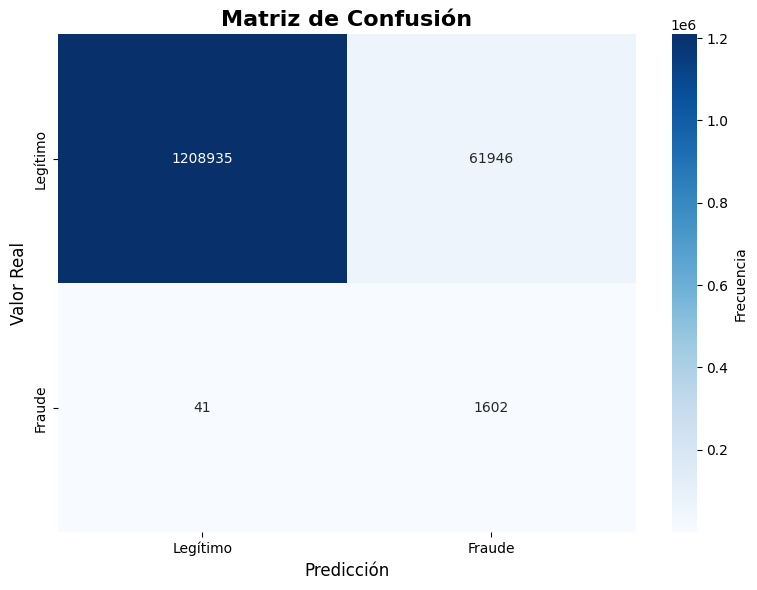

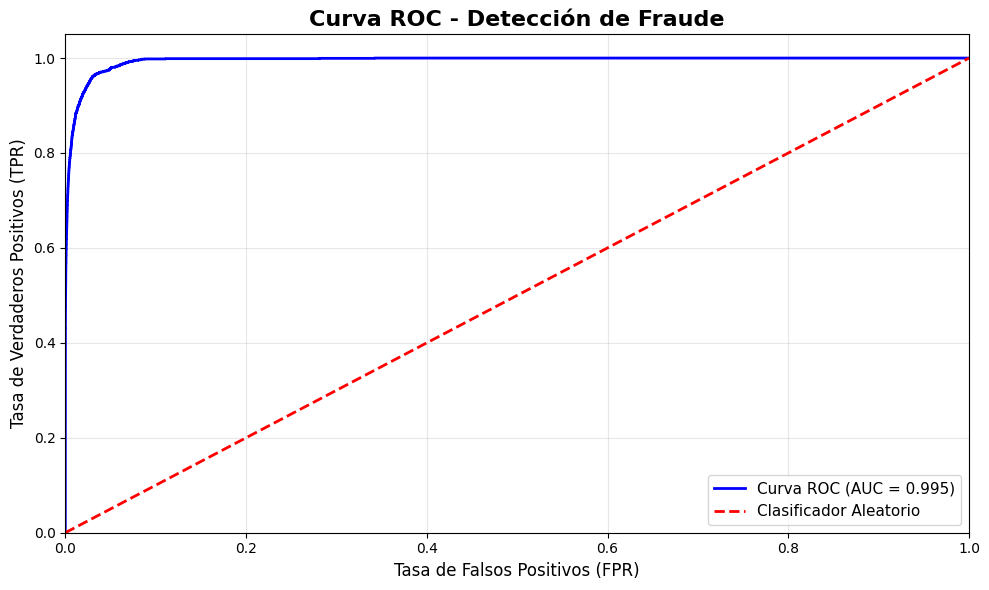

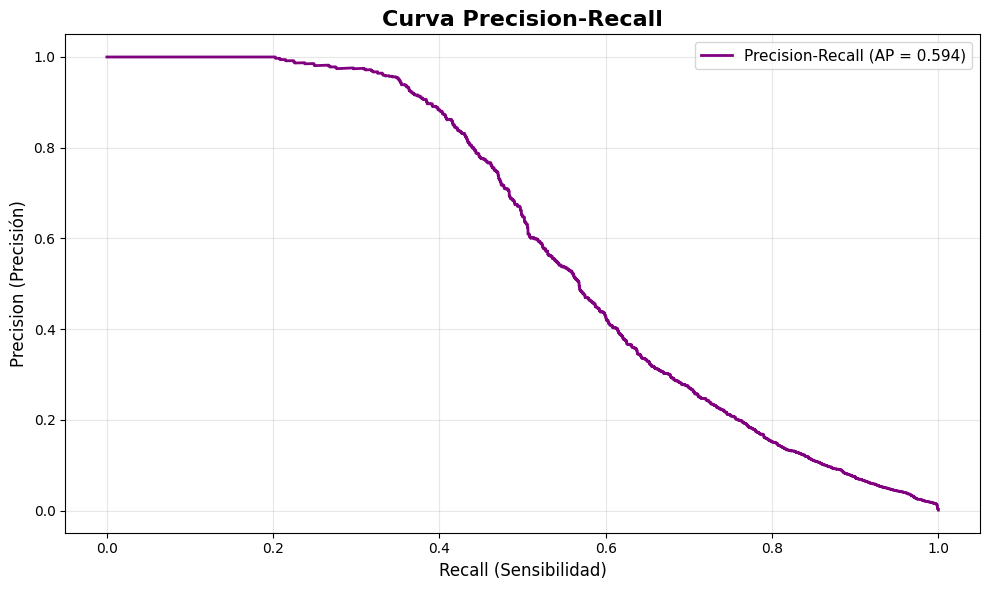

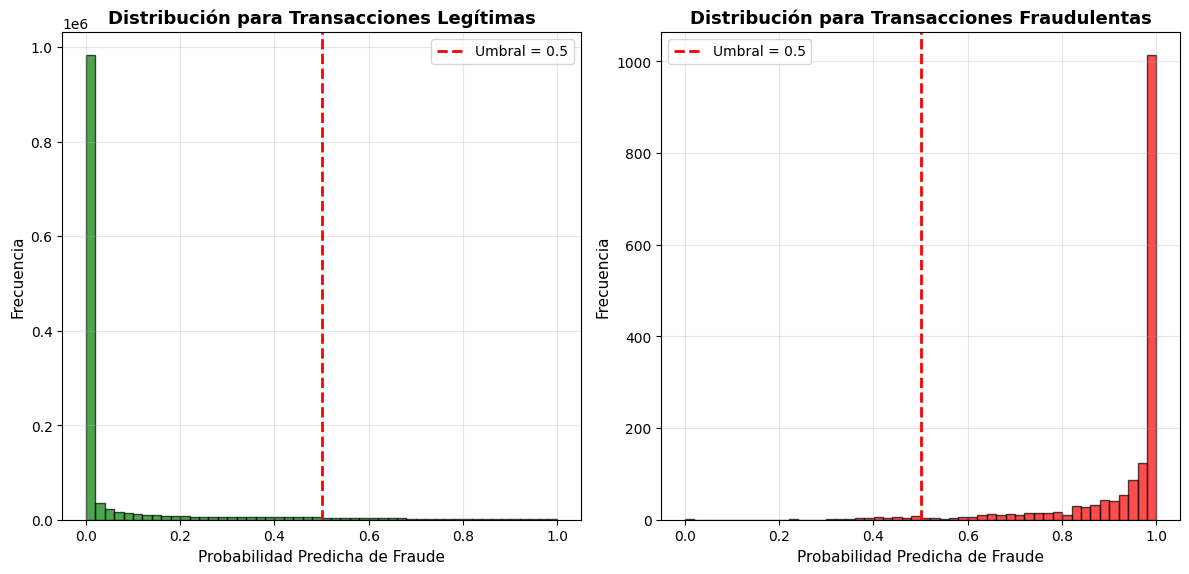

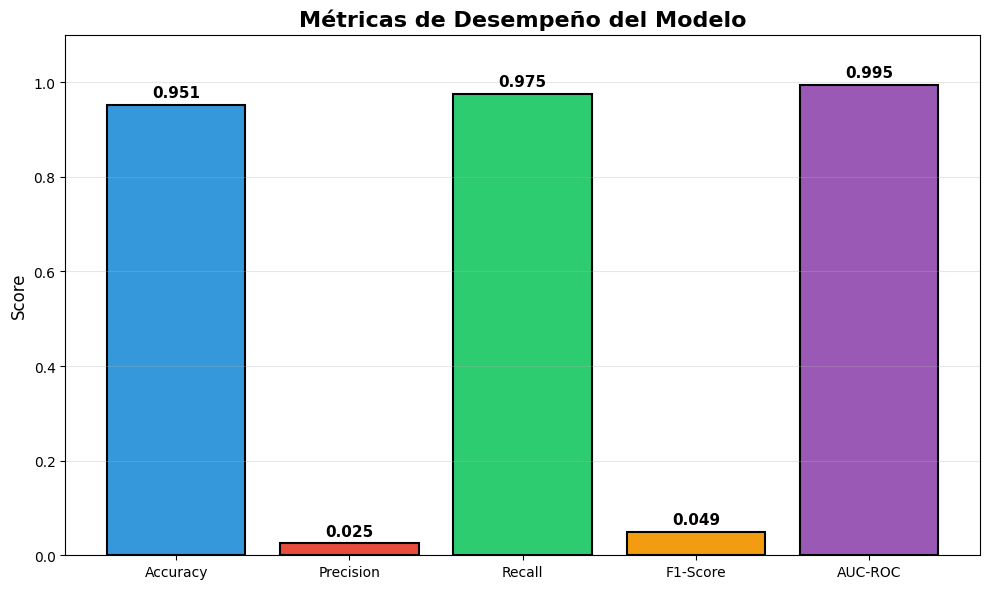

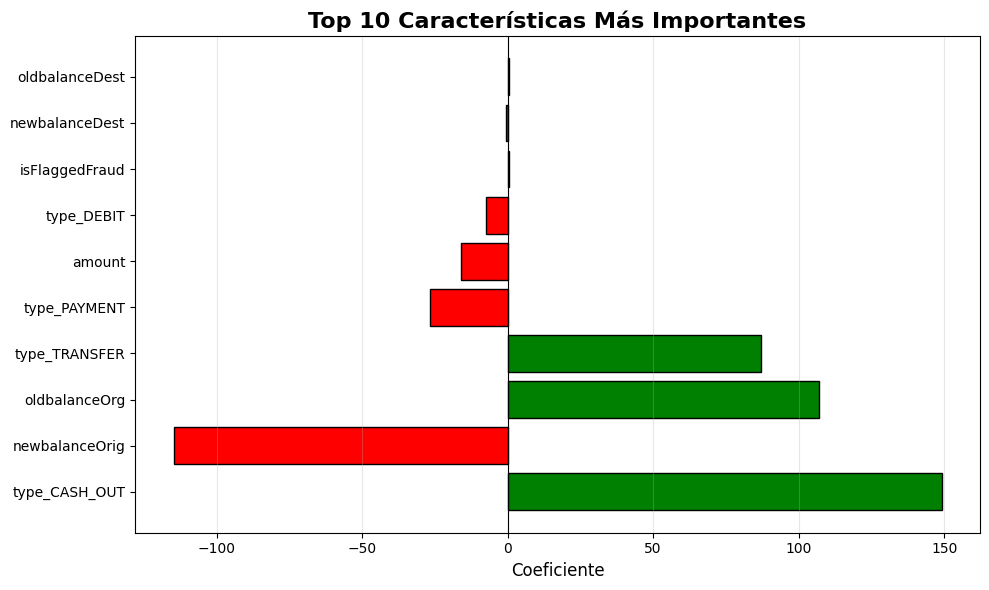

✅ Todas las gráficas generadas exitosamente!


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    roc_curve, 
    roc_auc_score,
    precision_recall_curve, 
    average_precision_score,
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report
)

# ============================================
# 1. PREDICCIONES
# ============================================
y_pred = modelo.predict(X_test_scaled)
y_pred_proba = modelo.predict_proba(X_test_scaled)[:, 1]

# ============================================
# 2. CALCULAR TODAS LAS MÉTRICAS
# ============================================
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Métricas individuales
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Curva ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# Curva Precision-Recall
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

# Probabilidades por clase
prob_fraude_real = y_pred_proba[y_test == 1]
prob_legitimo_real = y_pred_proba[y_test == 0]

# ============================================
# 3. IMPRIMIR MÉTRICAS
# ============================================
print("\n" + "="*60)
print("MÉTRICAS DE EVALUACIÓN")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_score:.4f}")
print(f"Avg Precision: {avg_precision:.4f}")

print("\n" + "="*60)
print("MATRIZ DE CONFUSIÓN")
print("="*60)
print(f"Verdaderos Negativos (TN): {TN}")
print(f"Falsos Positivos (FP):     {FP}")
print(f"Falsos Negativos (FN):     {FN}")
print(f"Verdaderos Positivos (TP): {TP}")

print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Legítimo', 'Fraude']))

# ============================================
# 4. GRÁFICA 1: MATRIZ DE CONFUSIÓN
# ============================================
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legítimo', 'Fraude'],
            yticklabels=['Legítimo', 'Fraude'],
            cbar_kws={'label': 'Frecuencia'})
plt.title('Matriz de Confusión', fontsize=16, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Predicción', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# 5. GRÁFICA 2: CURVA ROC
# ============================================
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Detección de Fraude', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 6. GRÁFICA 3: CURVA PRECISION-RECALL
# ============================================
plt.figure(figsize=(10, 6))
plt.plot(recall_curve, precision_curve, color='purple', lw=2, 
         label=f'Precision-Recall (AP = {avg_precision:.3f})')
plt.xlabel('Recall (Sensibilidad)', fontsize=12)
plt.ylabel('Precision (Precisión)', fontsize=12)
plt.title('Curva Precision-Recall', fontsize=16, fontweight='bold')
plt.legend(loc="best", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 7. GRÁFICA 4: DISTRIBUCIÓN DE PROBABILIDADES
# ============================================
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(prob_legitimo_real, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Probabilidad Predicha de Fraude', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.title('Distribución para Transacciones Legítimas', fontsize=13, fontweight='bold')
plt.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Umbral = 0.5')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(prob_fraude_real, bins=50, alpha=0.7, color='red', edgecolor='black')
plt.xlabel('Probabilidad Predicha de Fraude', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.title('Distribución para Transacciones Fraudulentas', fontsize=13, fontweight='bold')
plt.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Umbral = 0.5')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 8. GRÁFICA 5: MÉTRICAS COMPARATIVAS
# ============================================
metricas = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'AUC-ROC': auc_score
}

plt.figure(figsize=(10, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
bars = plt.bar(metricas.keys(), metricas.values(), color=colors, edgecolor='black', linewidth=1.5)

for bar, value in zip(bars, metricas.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Score', fontsize=12)
plt.title('Métricas de Desempeño del Modelo', fontsize=16, fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 9. GRÁFICA 6: IMPORTANCIA DE CARACTERÍSTICAS
# ============================================
import pandas as pd

importancias = pd.DataFrame({
    'Característica': X.columns,
    'Coeficiente': modelo.coef_[0]
})

importancias['Abs_Coef'] = importancias['Coeficiente'].abs()
importancias = importancias.sort_values('Abs_Coef', ascending=False)
top_features = importancias.head(10)

plt.figure(figsize=(10, 6))
colors_feat = ['red' if x < 0 else 'green' for x in top_features['Coeficiente']]
plt.barh(range(len(top_features)), top_features['Coeficiente'], color=colors_feat, edgecolor='black')
plt.yticks(range(len(top_features)), top_features['Característica'])
plt.xlabel('Coeficiente', fontsize=12)
plt.title('Top 10 Características Más Importantes', fontsize=16, fontweight='bold')
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Todas las gráficas generadas exitosamente!")